### Setup

In [10]:
import os
import sys
import pandas as pd
import torch
import numpy as np
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import logging

# Set current directory
print(f"📁 Current directory: {os.getcwd()}")

# Add necessary paths
sys.path.append("..")
sys.path.append("../src")

# Set up logging manually to avoid the config issue
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(name)-8s | %(levelname)-8s | %(message)s',
    datefmt='%H:%M:%S'
)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 1000)

plt.style.use('default')
sns.set_palette("husl")

📁 Current directory: /Users/sarayetel/Desktop/Research/Graph/RC-Element-Prediction-GNN/notebooks


### Import Modules

In [11]:
print("Importing modules with logger patch...")

# First, let's temporarily set an environment variable for the logger
import os
os.environ['LOGGER_CONFIG_PATH'] = "../configs/logger.yaml"
print(f"Set LOGGER_CONFIG_PATH to: {os.environ['LOGGER_CONFIG_PATH']}")

from src.data_manager.data_loader import HeteroDataLoader
from src.data_manager.graph_builder import HeteroGraphBuilder
print("Modules imported successfully!")

Importing modules with logger patch...
Set LOGGER_CONFIG_PATH to: ../configs/logger.yaml
Modules imported successfully!


In [12]:
# ==================================================
# 3. LOAD CONFIG
# ==================================================
display(Markdown("### Loading Configuration"))

config_path = "../configs/base.yaml"
print(f"Loading config from: {config_path}")

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Display key settings
config_summary = pd.DataFrame([
    {"Setting": "Project", "Value": config.get('project', {}).get('name', 'N/A')},
    {"Setting": "PE Enabled", "Value": config.get('data', {}).get('pe', {}).get('enabled', 'N/A')},
    {"Setting": "PE Type", "Value": config.get('data', {}).get('pe', {}).get('type', 'N/A')},
    {"Setting": "PE Dimension", "Value": config.get('data', {}).get('pe', {}).get('dim', 'N/A')},
    {"Setting": "Base Features", "Value": len(config.get('data', {}).get('feature_columns', []))}
])

display(config_summary)

### Loading Configuration

Loading config from: ../configs/base.yaml


,Setting,Value
0,Project,rc-element-prediction
1,PE Enabled,False
2,PE Type,N/A
3,PE Dimension,8
4,Base Features,41


In [13]:
# ==================================================
# 4. INITIALIZE DATA LOADER AND LOAD DATA
# ==================================================
display(Markdown("### Loading Data"))

loader = HeteroDataLoader("../configs/base.yaml")
print("✅ DataLoader initialized")

# Load samples
train_data_list = loader.load_all_samples("train")
print(f"Loaded {len(train_data_list)} samples")

# Show first few samples
sample_info = []
for i, sample in enumerate(train_data_list[:3]):
    beam_count = len(sample['nodes']['beam'])
    column_count = len(sample['nodes']['column'])
    edge_count = len(sample['edges_raw'])
    
    sample_info.append({
        "Sample": sample.get('sample_name', f'sample_{i}'),
        "Beams": beam_count,
        "Columns": column_count,
        "Total Nodes": beam_count + column_count,
        "Edges": edge_count
    })

sample_df = pd.DataFrame(sample_info)
display(sample_df)

# Show first sample details
first_sample = train_data_list[0]
display(Markdown(f"#### First Sample: {first_sample['sample_name']}"))
print(f"Beam columns: {len(first_sample['nodes']['beam'].columns)}")
print(f"Column columns: {len(first_sample['nodes']['column'].columns)}")
print(f"Feature columns (excluding Ele_Type, row_index): {len([col for col in first_sample['nodes']['beam'].columns if col not in ['Ele_Type', 'row_index']])}")

### Loading Data

19:55:11 | 📁 DATA   | ℹ️  INFO     | Initializing HeteroDataLoader with config: ../configs/base.yaml
19:55:11 | 📁 DATA   | ℹ️  INFO     | DataLoader initialized successfully
✅ DataLoader initialized
19:55:11 | 📁 DATA   | ℹ️  INFO     | Loading all samples from split: train
19:55:11 | 📁 DATA   | ℹ️  INFO     | Found 254 sample folders
19:55:11 | 📁 DATA   | ℹ️  INFO     | Loading sample: sample_1 (train)
19:55:12 | 📁 DATA   | ℹ️  INFO     | [sample_1] Edge node IDs validated successfully. All 458 referenced nodes exist in features.
19:55:12 | 📁 DATA   | ℹ️  INFO     | Successfully loaded sample sample_1
19:55:12 | 📁 DATA   | ℹ️  INFO     | Loading sample: sample_10 (train)
19:55:12 | 📁 DATA   | ⚠️  WARNING  | Multiple files found for pattern ../data/train/sample_10/Feature-*_english.xlsx, using first: ../data/train/sample_10/Feature-16_english.xlsx
19:55:12 | 📁 DATA   | ℹ️  INFO     | [sample_10] Edge node IDs validated successfully. All 260 referenced nodes exist in features.
19:55:12 |

,Sample,Beams,Columns,Total Nodes,Edges
0,sample_1,371,103,474,2804
1,sample_10,176,96,272,1946
2,sample_100,205,109,314,2028


#### First Sample: sample_1

Beam columns: 44
Column columns: 44
Feature columns (excluding Ele_Type, row_index): 42


In [14]:
# ==================================================
# 5. INITIALIZE GRAPH BUILDER WITH PATCH
# ==================================================
display(Markdown("### Initializing Graph Builder"))

# Create a patched GraphBuilder to avoid set_verbose issue
class PatchedGraphBuilder(HeteroGraphBuilder):
    """Patched version that fixes set_verbose method."""
    
    def set_verbose(self, verbose: bool):
        """Fixed version of set_verbose."""
        self.verbose = verbose
        level = logging.DEBUG if verbose else logging.INFO
        self.logger.setLevel(level)
        if verbose:
            self.logger.debug("Verbose mode enabled")

# Initialize
builder = PatchedGraphBuilder(config)
print("✅ GraphBuilder initialized (patched)")

# Show configuration
print(f"\n📊 Configuration:")
print(f"  PE enabled: {builder.pe_enabled}")
print(f"  PE type: {builder.pe_type}")
print(f"  PE dimension: {builder.pe_dim}")
print(f"  Base features: {len(config.get('data', {}).get('feature_columns', []))}")

### Initializing Graph Builder

19:55:56 | 🏗️ GRAPH  | ℹ️  INFO     | Initializing HeteroGraphBuilder
19:55:56 | 🏗️ GRAPH  | ℹ️  INFO     | GraphBuilder initialized successfully
✅ GraphBuilder initialized (patched)

📊 Configuration:
  PE enabled: False
  PE type: auto
  PE dimension: 8
  Base features: 41


In [15]:
# ==================================================
# 6. BUILD GRAPHS WITH PROPER ERROR HANDLING
# ==================================================
display(Markdown("### 🔨 Building Graphs"))

graphs = []
feature_counts = []

for i, sample in enumerate(train_data_list):
    sample_name = sample.get('sample_name', f'sample_{i}')
    print(f"\n[{i+1}/{len(train_data_list)}] Building: {sample_name}")
    
    # Build graph
    graph = builder.build_hetero_graph(sample)
    
    if graph is None:
        print("  ❌ Graph is None")
        continue
    
    graphs.append((sample_name, graph))
    
    try:
        # SAFELY check beam features
        if 'beam' in graph.node_types:
            beam_x = graph['beam'].x
            beam_shape = beam_x.shape
            print(f"  ✅ Beams: {beam_shape[0]} × {beam_shape[1]} features")
            
            # Calculate PE
            base_features = 42
            pe_features = max(0, beam_shape[1] - base_features)
            
            feature_counts.append({
                "sample": sample_name,
                "node_type": "beam",
                "nodes": beam_shape[0],
                "features": beam_shape[1],
                "base": base_features,
                "pe": pe_features,
                "has_pe": pe_features > 0
            })
        
        # SAFELY check column features
        if 'column' in graph.node_types:
            column_x = graph['column'].x
            column_shape = column_x.shape
            print(f"  ✅ Columns: {column_shape[0]} × {column_shape[1]} features")
            
            # Calculate PE
            base_features = 42
            pe_features = max(0, column_shape[1] - base_features)
            
            feature_counts.append({
                "sample": sample_name,
                "node_type": "column",
                "nodes": column_shape[0],
                "features": column_shape[1],
                "base": base_features,
                "pe": pe_features,
                "has_pe": pe_features > 0
            })
        
        # SAFELY count edges - FIXED VERSION
        print("  📍 Checking edges...")
        edge_patterns = [
            ('beam', 'to', 'beam'),
            ('column', 'to', 'column'),
            ('beam', 'to', 'column'),
            ('column', 'to', 'beam')
        ]
        
        for edge_type in edge_patterns:
            # Convert tuple to string for attribute access
            edge_attr = f"{edge_type[0]}_{edge_type[1]}_{edge_type[2]}"
            
            # Check if this edge type exists in the graph
            if hasattr(graph, edge_attr):
                edge_data = getattr(graph, edge_attr)
                if hasattr(edge_data, 'edge_index'):
                    count = edge_data.edge_index.shape[1]
                    if count > 0:
                        print(f"    {edge_type}: {count} edges")
        
    except Exception as e:
        print(f"  ⚠️ Error analyzing graph: {e}")

### 🔨 Building Graphs


[1/254] Building: sample_1
19:55:56 | 🏗️ GRAPH  | ℹ️  INFO     | Building hetero graph for sample: sample_1
19:55:56 | 🏗️ GRAPH  | ℹ️  INFO     | sample_1: dropped 70 invalid (0,0)/missing-label nodes
19:55:56 | 🏗️ GRAPH  | ℹ️  INFO     | ✅ Built graph for sample_1
  ✅ Beams: 301 × 41 features
  ✅ Columns: 103 × 41 features
  📍 Checking edges...

[2/254] Building: sample_10
19:55:56 | 🏗️ GRAPH  | ℹ️  INFO     | Building hetero graph for sample: sample_10
19:55:56 | 🏗️ GRAPH  | ℹ️  INFO     | ✅ Built graph for sample_10
  ✅ Beams: 176 × 41 features
  ✅ Columns: 96 × 41 features
  📍 Checking edges...

[3/254] Building: sample_100
19:55:56 | 🏗️ GRAPH  | ℹ️  INFO     | Building hetero graph for sample: sample_100
19:55:57 | 🏗️ GRAPH  | ℹ️  INFO     | ✅ Built graph for sample_100
  ✅ Beams: 205 × 41 features
  ✅ Columns: 109 × 41 features
  📍 Checking edges...

[4/254] Building: sample_101
19:55:57 | 🏗️ GRAPH  | ℹ️  INFO     | Building hetero graph for sample: sample_101
19:55:57 | 🏗️ GRAP

In [16]:
# ==================================================
# 7. SAVE THE FRESHLY-BUILT GRAPHS  (this actually writes to disk)
# ==================================================
import os, torch

os.makedirs("../data/graphs", exist_ok=True)
torch.save(graphs, "../data/graphs/train_graphs.pt")
print(f"Saved {len(graphs)} graphs to ../data/graphs/train_graphs.pt")

# sanity check: confirm the NEW format (raw features + feature_names)
_, _g0 = graphs[0]
print("beam feature width:", _g0["beam"].x.shape[1],
      "| has feature_names:", hasattr(_g0["beam"], "feature_names"),
      "| num_raw_features:", getattr(_g0["beam"], "num_raw_features", "MISSING"))
assert hasattr(_g0["beam"], "feature_names"), "Builder did not store feature_names -> src not updated!"
print("New-format graphs saved correctly.")


Saved 254 graphs to ../data/graphs/train_graphs.pt
beam feature width: 41 | has feature_names: True | num_raw_features: 41
New-format graphs saved correctly.


In [18]:
# ==================================================
# 8b. BUILD + SAVE THE EXTERNAL TEST GRAPHS
# ==================================================
# Reuses the SAME loader + builder + config as train, so test graphs have
# IDENTICAL feature columns/order (required for the model + scalers). Saves to a
# SEPARATE file so train_graphs.pt is never touched. Run cells 1-6 first (imports,
# config, loader, builder). Requires data/test/sample_N/ organized + translated
# to _english by the notebook-0 test-prep cell.
display(Markdown("### 🔨 Building TEST graphs (external test set)"))

test_data_list = loader.load_all_samples("test")
print(f"Loaded {len(test_data_list)} test samples")

test_graphs = []
for i, sample in enumerate(test_data_list):
    sname = sample.get("sample_name", f"sample_{i}")
    g = builder.build_hetero_graph(sample)
    if g is None:
        print(f"  ❌ {sname}: build returned None"); continue
    test_graphs.append((sname, g))
print(f"Built {len(test_graphs)}/{len(test_data_list)} test graphs")

os.makedirs("../data/graphs", exist_ok=True)
torch.save(test_graphs, "../data/graphs/test_graphs.pt")
print(f"Saved {len(test_graphs)} graphs to ../data/graphs/test_graphs.pt")

# sanity: identical feature schema to train (else model/scalers won't align)
_, _t0 = test_graphs[0]
print("beam feature width:", _t0["beam"].x.shape[1],
      "| has feature_names:", hasattr(_t0["beam"], "feature_names"),
      "| num_raw_features:", getattr(_t0["beam"], "num_raw_features", "MISSING"))
assert hasattr(_t0["beam"], "feature_names"), "Builder did not store feature_names"
print("✅ Test graphs saved correctly -> data/graphs/test_graphs.pt")


### 🔨 Building TEST graphs (external test set)

19:59:39 | 📁 DATA   | ℹ️  INFO     | Loading all samples from split: test
19:59:39 | 📁 DATA   | ℹ️  INFO     | Found 59 sample folders
19:59:39 | 📁 DATA   | ℹ️  INFO     | Loading sample: sample_1 (test)
19:59:39 | 📁 DATA   | ℹ️  INFO     | [sample_1] Edge node IDs validated successfully. All 63 referenced nodes exist in features.
19:59:39 | 📁 DATA   | ℹ️  INFO     | Successfully loaded sample sample_1
19:59:39 | 📁 DATA   | ℹ️  INFO     | Loading sample: sample_10 (test)
19:59:39 | 📁 DATA   | ℹ️  INFO     | [sample_10] Edge node IDs validated successfully. All 171 referenced nodes exist in features.
19:59:39 | 📁 DATA   | ℹ️  INFO     | Successfully loaded sample sample_10
19:59:39 | 📁 DATA   | ℹ️  INFO     | Loading sample: sample_11 (test)
19:59:39 | 📁 DATA   | ℹ️  INFO     | [sample_11] Edge node IDs validated successfully. All 93 referenced nodes exist in features.
19:59:39 | 📁 DATA   | ℹ️  INFO     | Successfully loaded sample sample_11
19:59:39 | 📁 DATA   | ℹ️  INFO     | Loading 

### 📊 Feature Analysis Results

#### 📋 Detailed Feature Counts

,sample,node_type,nodes,features,base,pe,has_pe
0,sample_1,beam,301,41,42,0,False
1,sample_1,column,103,41,42,0,False
2,sample_10,beam,176,41,42,0,False
3,sample_10,column,96,41,42,0,False
4,sample_100,beam,205,41,42,0,False
...,...,...,...,...,...,...,...
503,sample_97,column,27,41,42,0,False
504,sample_98,beam,311,41,42,0,False
505,sample_98,column,125,41,42,0,False
506,sample_99,beam,149,41,42,0,False


#### 📈 Summary

nodes          features             base    pe has_pe
             mean min  max     mean  std count first first  first
node_type                                                        
beam       150.39   7  827     41.0  0.0   254    42     0  False
column      73.02   6  427     41.0  0.0   254    42     0  False


🔍 Consistency Check:
✅ Beam features consistent: 41
✅ Column features consistent: 41

⚠️ No Positional Encoding detected
  Expected: 42 base + 8 PE = 50 total
  Actual: 41 features


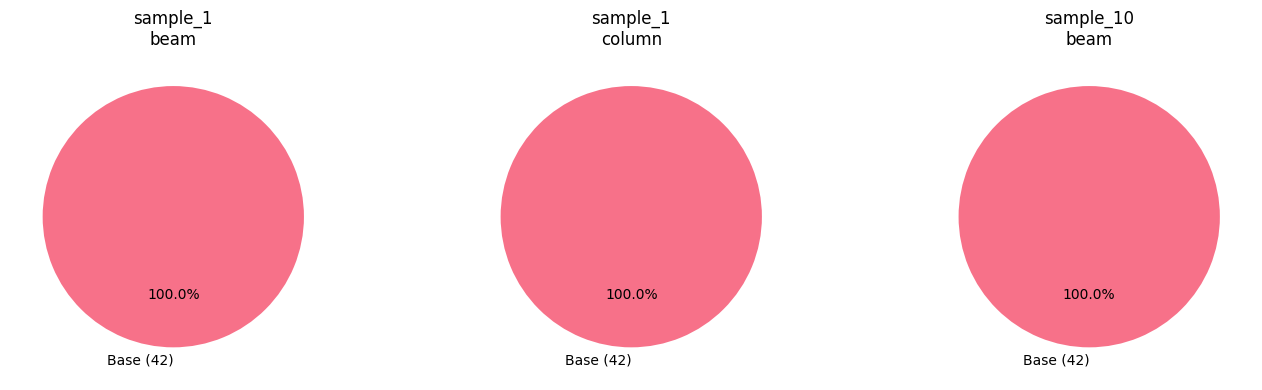

In [19]:
# ==================================================
# 7. DISPLAY FEATURE ANALYSIS
# ==================================================
display(Markdown("### 📊 Feature Analysis Results"))

if feature_counts:
    # Create DataFrame
    feat_df = pd.DataFrame(feature_counts)
    
    # Display detailed table
    display(Markdown("#### 📋 Detailed Feature Counts"))
    display(feat_df[['sample', 'node_type', 'nodes', 'features', 'base', 'pe', 'has_pe']])
    
    # Summary statistics
    display(Markdown("#### 📈 Summary"))
    
    summary = feat_df.groupby('node_type').agg({
        'nodes': ['mean', 'min', 'max'],
        'features': ['mean', 'std', 'count'],
        "base": 'first',
        "pe": 'first',
        'has_pe': 'first'
    }).round(2)
    
    display(summary)
    
    # Check consistency
    beam_features = feat_df[feat_df['node_type'] == 'beam']['features'].unique()
    column_features = feat_df[feat_df['node_type'] == 'column']['features'].unique()
    
    print("\n🔍 Consistency Check:")
    if len(beam_features) == 1:
        print(f"✅ Beam features consistent: {beam_features[0]}")
    else:
        print(f"⚠️ Beam features vary: {beam_features}")
    
    if len(column_features) == 1:
        print(f"✅ Column features consistent: {column_features[0]}")
    else:
        print(f"⚠️ Column features vary: {column_features}")
    
    # Check if PE was added
    if feat_df['has_pe'].any():
        pe_dim = feat_df['pe'].iloc[0]
        total_features = feat_df['features'].iloc[0]
        base_features = feat_df['base'].iloc[0]
        
        print(f"\n🎯 Positional Encoding:")
        print(f"  Base features: {base_features}")
        print(f"  PE dimension: {pe_dim}")
        print(f"  Total features: {total_features}")
        print(f"  Formula: {base_features} + {pe_dim} = {total_features}")
        
        if pe_dim == config.get('data', {}).get('pe', {}).get('dim', 8):
            print(f"✅ PE dimension matches config: {pe_dim}")
        else:
            print(f"⚠️ PE dimension mismatch: expected {config.get('data', {}).get('pe', {}).get('dim', 8)}, got {pe_dim}")

    else:
        print(f"\n⚠️ No Positional Encoding detected")
        print(f"  Expected: 42 base + {config.get('data', {}).get('pe', {}).get('dim', 8)} PE = {42 + config.get('data', {}).get('pe', {}).get('dim', 8)} total")
        print(f"  Actual: {feat_df['features'].iloc[0]} features")
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    # Feature composition
    for i, (sample, node_type) in enumerate(zip(feat_df['sample'], feat_df['node_type'])):
        row = feat_df[(feat_df['sample'] == sample) & (feat_df['node_type'] == node_type)].iloc[0]
        
        if i < 3:  # Show first 3
            labels = [f"Base ({int(row['base'])})"]
            sizes = [row['base']]

            if row['pe'] > 0:
                labels.append(f"PE ({int(row['pe'])})")
                sizes.append(row['pe'])
            
            axes[i].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
            axes[i].set_title(f"{sample}\n{node_type}")
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ No feature data collected")

In [20]:
for i, col in enumerate(config['data']['feature_columns']):
    print(f"{i:02d} | {col}")

00 | Structural_System
01 | Opening_Status
02 | Height_Difference
03 | Roof_Area_Difference_Excluding_Roof
04 | Relative_to_Horizontal_Axis
05 | Relative_to_Vertical_Axis
06 | Beam_Arrangement
07 | Width_to_Length_Ratio
08 | Number_of_Horizontal_Frames
09 | Number_of_Vertical_Frames
10 | Frame_Ratio_X_to_Y
11 | Structure_Height
12 | Number_of_Floors
13 | Earthquake_Coefficient
14 | Allowable_Drift
15 | Beam_Concrete_Compressive_Strength
16 | Column_Concrete_Compressive_Strength
17 | Dynamic_Analysis
18 | Static_Analysis
19 | X1
20 | Y1
21 | Z1
22 | X2
23 | Y2
24 | Z2
25 | Length
26 | Angle
27 | Story
28 | Boundary
29 | Alignment
30 | GravityForce
31 | EX
32 | EY
33 | CMX
34 | CRX
35 | DeltaX
36 | CMY
37 | CRY
38 | DeltaY
39 | CRXi
40 | CRYi
